# Concevez une application au service de la sante publique
#  Partie 2 : Analyse Exploratoire 

## Les packages


In [14]:
%matplotlib inline
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random
import pickle
from sklearn.linear_model import LinearRegression 
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, validation_curve, GridSearchCV
from scipy import stats,spatial

## Importation des Données 

In [115]:
train= pd.read_csv("train_filled_clean.csv")
test= pd.read_csv("test.csv")


In [116]:
train.shape

(74361, 23)

In [48]:
test.shape

(41479, 18)

In [124]:
train[train.columns[:-3]] = train[train.columns[:-3]].applymap(abs)


In [125]:
train.head()


,energy-kcal_100g,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,...,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,nutrition-score-fr_100g,nan,nutriscore_score,nutriscore_grade,nova_group
0,1.807960,1.824195,2.058978,0.625751,0.049227,0.039956,0.058311,0.072346,1.046215,1.604822,...,0.010793,0.024249,0.020496,0.009061,0.312067,1.092341,0,19.0,e,4.0
1,0.246770,0.252990,0.304260,0.693760,0.049227,0.039956,1.148851,0.792155,1.401106,0.637594,...,0.010778,0.024249,0.124528,0.024402,0.312067,0.151041,0,8.0,c,4.0
2,1.055648,1.067184,0.941103,0.429224,0.049227,0.039956,0.293360,0.981923,1.046215,0.740260,...,0.010793,0.024249,0.007822,0.005549,1.112343,0.075028,0,10.0,c,3.0
3,1.383724,1.398036,1.500041,2.078322,0.049227,0.039956,0.352298,0.147469,1.249010,0.308628,...,0.010793,0.024249,0.006337,0.010419,0.501881,0.527167,0,14.0,d,4.0
4,1.242312,1.255076,0.829047,0.410216,0.049227,0.039956,1.159086,0.775017,0.260383,0.062084,...,0.010793,0.047584,0.049244,0.019063,0.312067,0.527167,0,14.0,d,4.0


In [128]:
train.corr()

,energy-kcal_100g,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,nutrition-score-fr_100g,nutriscore_score,nova_group
energy-kcal_100g,1.000000,0.989582,0.601421,0.189434,0.011866,-0.012202,-0.017037,-0.061274,-0.013819,0.042150,-0.000220,-0.000220,0.001527,0.002945,-0.012137,0.008076,0.255070,0.200003,-0.059368,-0.196164
energy_100g,0.989582,1.000000,0.603940,0.184217,0.011220,-0.012331,-0.014655,-0.059706,-0.012052,0.042444,-0.000252,-0.000252,0.001593,0.003280,-0.012161,0.008301,0.258206,0.202193,-0.058261,-0.198415
fat_100g,0.601421,0.603940,1.000000,0.368160,0.016882,0.001616,-0.058890,-0.001754,0.133685,0.231721,-0.000054,-0.000054,0.000251,0.000609,0.003001,0.010956,0.280408,0.132270,0.093052,-0.191704
saturated-fat_100g,0.189434,0.184217,0.368160,1.000000,-0.008468,0.013425,0.075235,0.186020,-0.004655,0.147230,-0.001044,-0.001044,-0.000713,-0.001433,0.024721,0.019306,-0.028384,0.292503,0.308603,0.017563
trans-fat_100g,0.011866,0.011220,0.016882,-0.008468,1.000000,0.004015,-0.002429,0.013829,-0.004727,-0.010757,-0.000193,-0.000193,-0.000595,-0.000363,0.002512,-0.000294,-0.007647,0.006624,0.031130,0.011828
cholesterol_100g,-0.012202,-0.012331,0.001616,0.013425,0.004015,1.000000,0.007371,-0.002546,0.000478,0.022744,0.002622,0.002622,-0.000206,0.000182,0.454001,-0.000213,-0.003415,-0.002141,0.005157,-0.008330
carbohydrates_100g,-0.017037,-0.014655,-0.058890,0.075235,-0.002429,0.007371,1.000000,0.482867,0.018886,0.037530,-0.002779,-0.002779,0.000699,0.006770,0.012367,0.011798,-0.033608,0.045033,0.052553,-0.102983
sugars_100g,-0.061274,-0.059706,-0.001754,0.186020,0.013829,-0.002546,0.482867,1.000000,-0.038116,-0.026893,0.000060,0.000060,-0.001016,0.003163,-0.000639,0.000541,-0.030479,0.165376,0.365241,0.096970
fiber_100g,-0.013819,-0.012052,0.133685,-0.004655,-0.004727,0.000478,0.018886,-0.038116,1.000000,0.185810,-0.000696,-0.000696,0.010813,-0.000329,0.003845,0.017547,0.067148,0.004714,-0.117423,-0.158279
proteins_100g,0.042150,0.042444,0.231721,0.147230,-0.010757,0.022744,0.037530,-0.026893,0.185810,1.000000,-0.000174,-0.000174,0.002461,0.000083,0.027182,-0.003061,0.095038,-0.013601,0.067190,-0.122416


La colonne "nutriscore_score" a une corrélation positive modérée avec les colonnes "energy_100g" (0.675766), "fat_100g" (0.575387), "saturated-fat_100g" (0.603015), "sugars_100g" (0.461097) et "sum_100g" (0.568785). Cela suggère qu'une augmentation de ces variables est généralement associée à une augmentation du score nutriscore.

La colonne "nutriscore_score" a une corrélation négative modérée avec la colonne "fruits-vegetables-nuts-estimate-from-ingredients_100g" (-0.159322). Cela indique qu'une augmentation de la quantité de fruits, légumes et noix dans le produit est généralement associée à une diminution du score nutriscore.

Certaines colonnes, comme "fiber_100g", "proteins_100g", "salt_100g" et "sodium_100g", ont une corrélation plus faible avec la colonne "nutriscore_score", indiquant une relation moins significative.

In [150]:
train=train.drop(columns='carbohydrates_100g')

In [151]:
train=train.drop(columns='trans-fat_100g')

In [152]:
train=train.drop(columns='saturated-fat_100g')

In [153]:
train=train.drop(columns='sodium_100g')

# Analyse univariée


## Quelques graphes des différents features : 

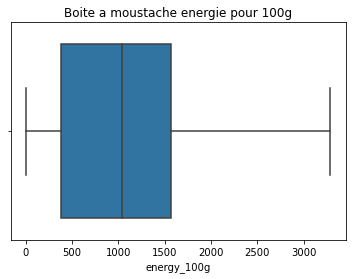

In [56]:
sns.boxplot(x='energy_100g', data = train)
plt.title('Boite a moustache energie pour 100g')
plt.savefig('energy-kj_fr_boxplot.jpg', bbox_inches='tight')
plt.show()

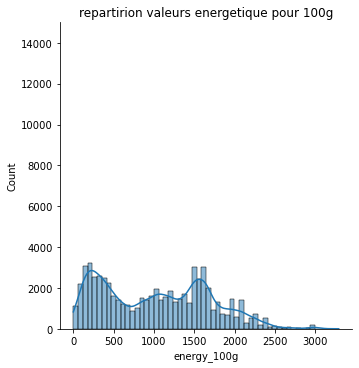

In [57]:
sns.displot(train['energy_100g'], kde = True)
plt.ylim(0, 15000)
plt.title('repartirion valeurs energetique pour 100g')
plt.savefig('energy_fr.jpg', bbox_inches='tight')
plt.show()


In [89]:
train['energy_100g'].describe()


count    64438.000000
mean      1027.405488
std        669.694685
min          0.000000
25%        381.000000
50%       1038.000000
75%       1569.000000
max       3289.000000
Name: energy_100g, dtype: float64

In [164]:
def plot_univ(df, colonne, label, ylim):
    # Affichage des statistiques descriptives de la colonne
    print(f'analyse univariée colonne {colonne}')
    print(f'moyenne : {df[colonne].mean()}')
    print(f'ecart type : {df[colonne].std()}')
    print(f'min : {df[colonne].min()}')
    print(f'25% : {df[colonne].quantile(0.25)}')
    print(f'50% : {df[colonne].quantile(0.5)}')
    print(f'75% : {df[colonne].quantile(0.75)}')
    print(f'max : {df[colonne].max()}')

    # Boîte à moustaches (boxplot)
    sns.boxplot(x=colonne, data=df)
    plt.title('Boite a moustache '+label+' pour 100g')
    file = label+'_boxplot.jpg'
    plt.savefig(file, bbox_inches='tight')
    plt.show()    

    # Distribution des valeurs (histogramme)
    sns.displot(df[colonne], kde=True)
    plt.ylim(0, ylim)
    plt.title('repartition '+label+' pour 100g')
    file = label+'_dist.jpg'
    plt.savefig(file, bbox_inches='tight')
    plt.show()

analyse univariée colonne fat_100g
moyenne : 10.234397434116108
ecart type : 12.799959930833605
min : 0.0
25% : 0.0
50% : 4.709999999999999
75% : 16.67
max : 100.0


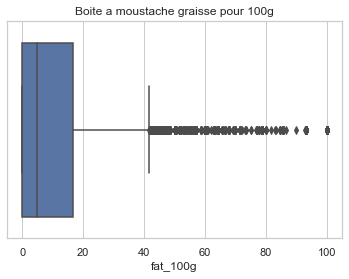

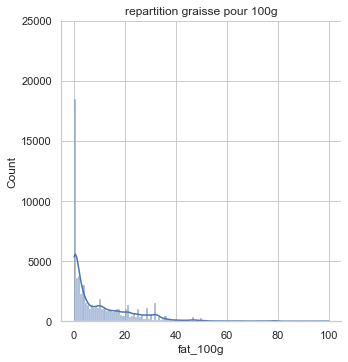

In [63]:
plot_univ(train,'fat_100g','graisse',25000)


analyse univariée colonne proteins_100g
moyenne : 6.98265969162927
ecart type : 7.526215379694863
min : 0.0
25% : 1.6399999999999997
50% : 4.61
75% : 10.0
max : 100.0


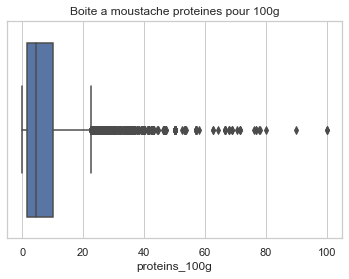

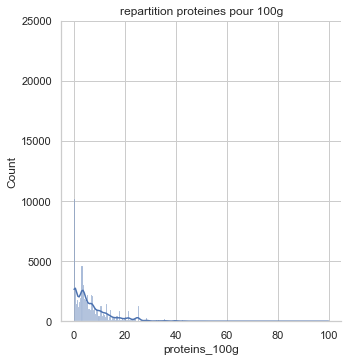

In [64]:
plot_univ(train,'proteins_100g','proteines',25000)


analyse univariée colonne sugars_100g
moyenne : 16.239140319989538
ecart type : 17.41781644065149
min : 0.0099999999999997
25% : 3.5699999999999985
50% : 13.09
75% : 20.59
max : 100.0


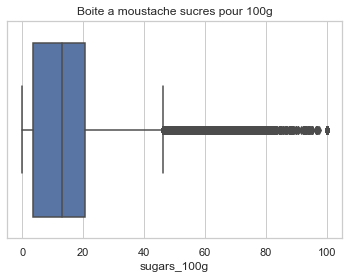

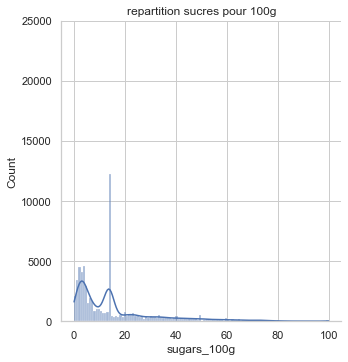

In [65]:
plot_univ(train,'sugars_100g','sucres',25000)


analyse univariée colonne fiber_100g
moyenne : 1.7188010086128935
ecart type : 2.422677860430307
min : 0.0
25% : 0.0
50% : 0.8999999999999999
75% : 2.6
max : 50.0


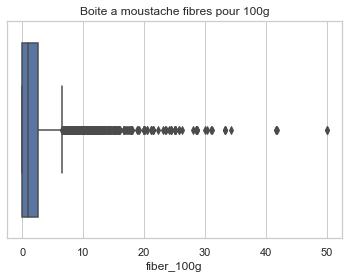

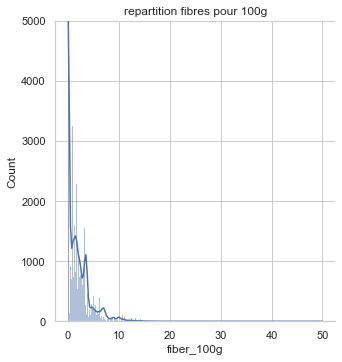

In [66]:
plot_univ(train,'fiber_100g','fibres',5000)


analyse univariée colonne saturated-fat_100g
moyenne : 3.9091293956634443
ecart type : 5.917590042773718
min : 0.0
25% : 0.0
50% : 1.1799999999999995
75% : 6.06
max : 96.97


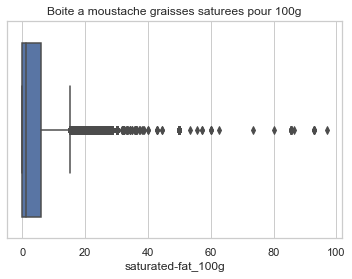

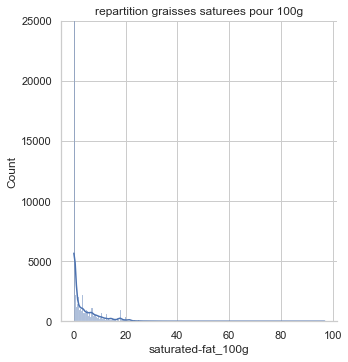

In [67]:
plot_univ(train,'saturated-fat_100g','graisses saturees',25000)


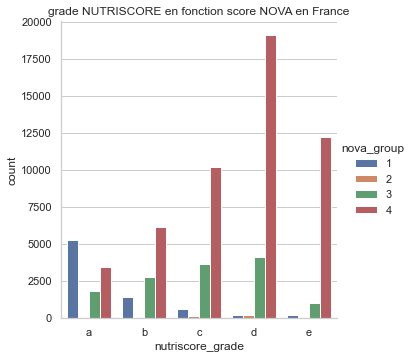

In [130]:
sns.catplot(x='nutriscore_grade', kind='count',data = train, hue='nova_group', order= ['a','b','c','d','e'], hue_order = [1,2,3,4])
plt.title('grade NUTRISCORE en fonction score NOVA en France')
plt.savefig('nutriscore_grade_fr_NOVA_catplot.jpg', bbox_inches='tight')
plt.show()

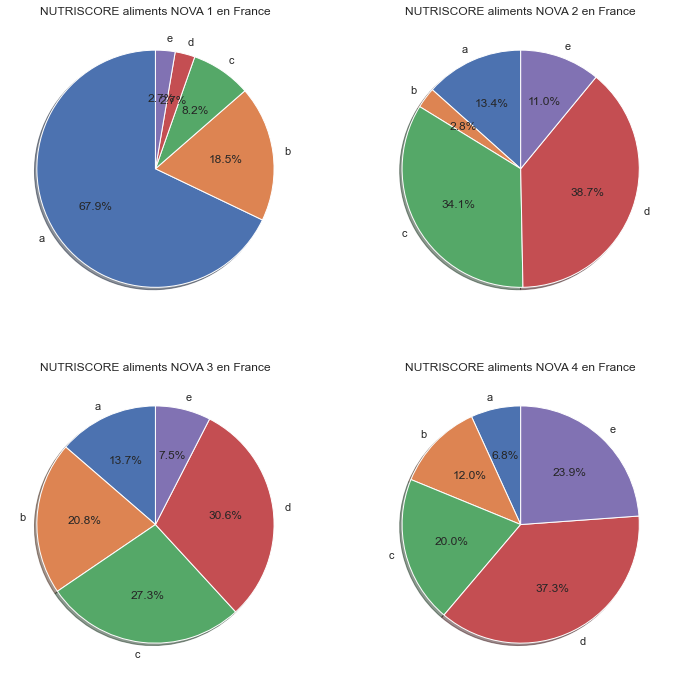

In [129]:
plt.rcParams["figure.figsize"]=[12,12]

plt.subplot(221)
data=train[train['nova_group']==1]['nutriscore_grade'].value_counts().sort_index()
plt.pie(data.values, labels=data.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('NUTRISCORE aliments NOVA 1 en France')

plt.subplot(222)
data=train[train['nova_group']==2]['nutriscore_grade'].value_counts().sort_index()
plt.pie(data.values, labels=data.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('NUTRISCORE aliments NOVA 2 en France')

plt.subplot(223)
data=train[train['nova_group']==3]['nutriscore_grade'].value_counts().sort_index()
plt.pie(data.values, labels=data.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('NUTRISCORE aliments NOVA 3 en France')

plt.subplot(224)
data=train[train['nova_group']==4]['nutriscore_grade'].value_counts().sort_index()
plt.pie(data.values, labels=data.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('NUTRISCORE aliments NOVA 4 en France')

plt.savefig('nutriscore_score_fr_NOVA_pieplot.jpg', bbox_inches='tight')
plt.show()

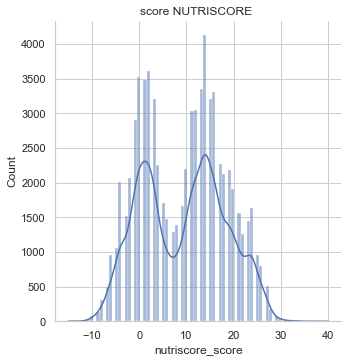

In [131]:
sns.displot(train['nutriscore_score'], kde = True)
plt.title('score NUTRISCORE ')
plt.savefig('nutriscore_score_fr.jpg', bbox_inches='tight')
plt.show()

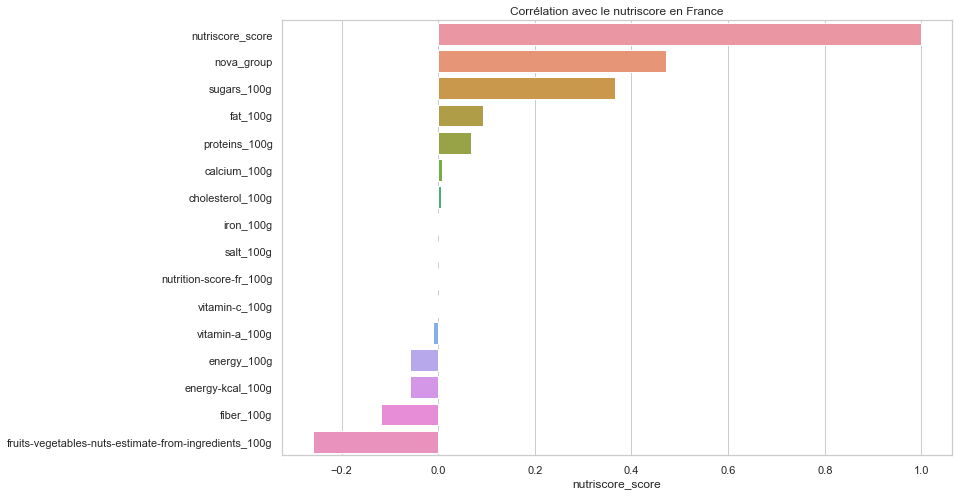

In [168]:
df_corr = train.corr()  # Calcule la matrice de corrélation entre les variables du dataframe
corr_nutri = df_corr.sort_values('nutriscore_score', ascending=False)  # Trie les corrélations par rapport au nutriscore_score de manière décroissante
plt.figure(figsize=(12, 8))  # Définit la taille de la figure du graphique à barres
sns.barplot(x=corr_nutri['nutriscore_score'], y=corr_nutri.index)  # Crée un graphique à barres des corrélations avec le nutriscore_score
plt.title('Corrélation avec le nutriscore en France')  # Ajoute un titre au graphique
plt.savefig('corr_nutriscore_fr.jpg', bbox_inches='tight')  # Sauvegarde le graphique en tant qu'image
plt.show()  # Affiche 


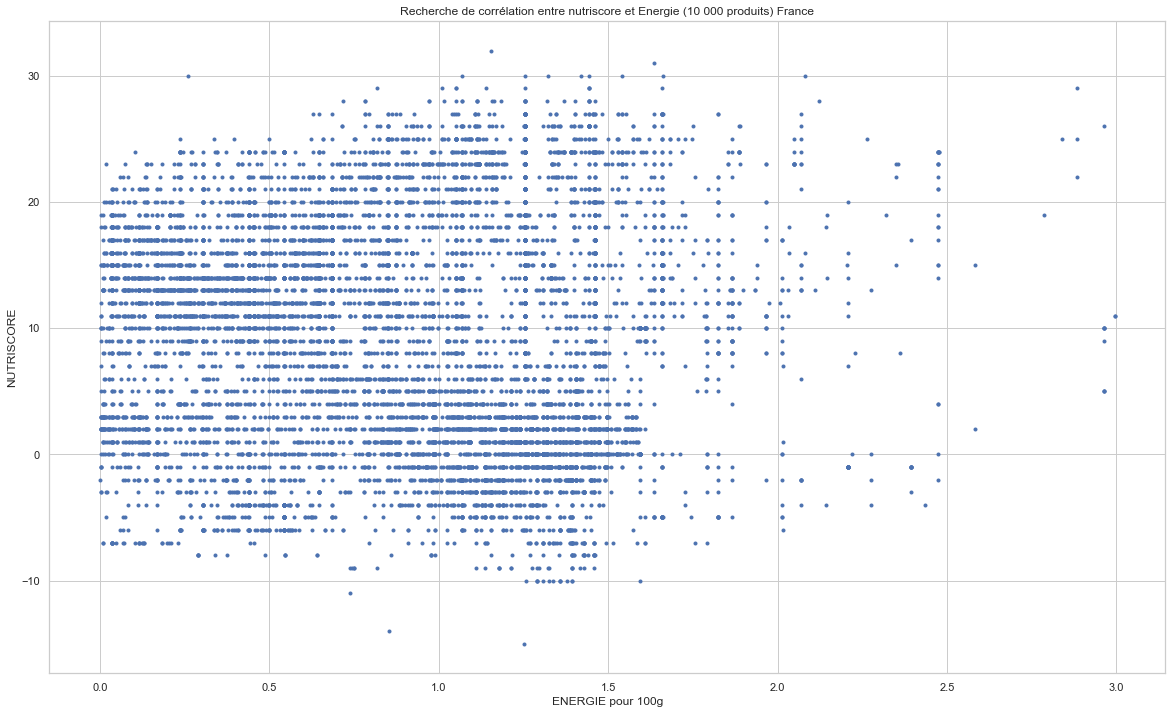

In [169]:
df = train.sample(10000)  # Échantillonne aléatoirement 10 000 lignes du dataframe train
plt.figure(figsize=[20, 12])  # Définit la taille de la figure du graphique de dispersion
plt.plot(df['energy_100g'], df['nutriscore_score'], linestyle='', marker='.')  # Crée un graphique de dispersion des valeurs de nutriscore_score et energy_100g
plt.title('Recherche de corrélation entre nutriscore et Energie (10 000 produits) France')  # Ajoute un titre au graphique
plt.xlabel("ENERGIE pour 100g")  # Ajoute une étiquette à l'axe des abscisses
plt.ylabel("NUTRISCORE")  # Ajoute une étiquette à l'axe des ordonnées
plt.savefig('rech_corr_nutriscore_energy_fr.jpg', bbox_inches='tight')  # Sauvegarde le graphique en tant qu'image
plt.show()  # Affiche le graphique de dispersion

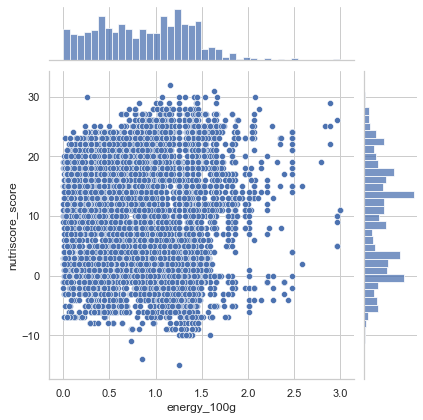

In [170]:
sns.jointplot(x='energy_100g', y='nutriscore_score', data=df)  # Crée un graphique de dispersion avec des histogrammes des variables energy_100g et nutriscore_score
plt.savefig('rech_corr_nutriscore_energy-kj_fr_jointplot.jpg', bbox_inches='tight')  # Sauvegarde le graphique en tant qu'image
plt.show()  # Affiche le graphique de dispersion

# Tests Statistiques 

## Test de Pearson

Hypothèse nulle: la corrélation entre les deux caractéristiques étudiées est nulle

Rejet d'hypothèse nulle p_valeur = 0

=> La corrélation entre nos fonctionnalités n'est pas nulle

Text(0.5, 0.98, 'Corrélation Nutriscore_score avec autres features')

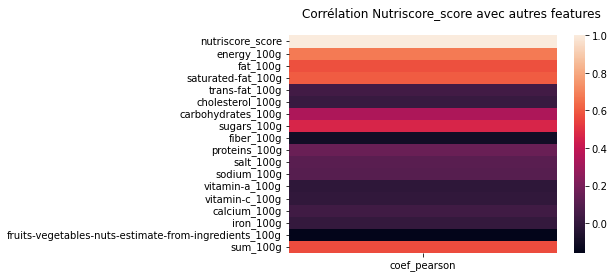

In [58]:
sns.heatmap(test_pear.drop(columns=['p_value']))
plt.suptitle('Corrélation Nutriscore_score avec autres features')

Nous pouvons observer une corrélation significative entre les caractéristiques suivantes:

énergie (energy)
graisses et graisses saturées (fat & saturated-fat )
sucres (sugars)

<AxesSubplot:>

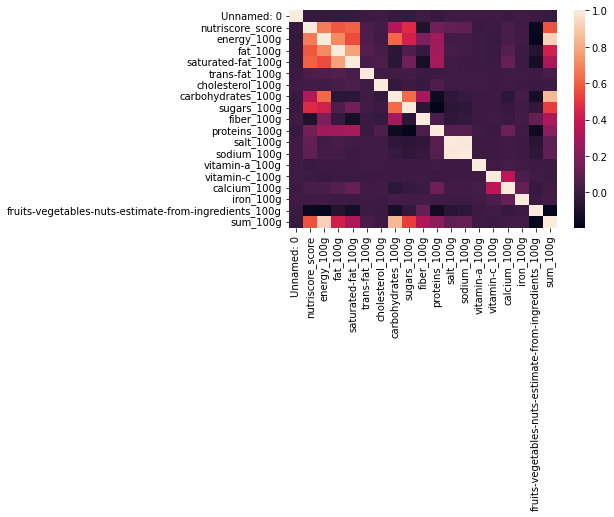

In [59]:
sns.heatmap(train.corr())


# #Test de normalité (Kolmogorov-Smirnov)

In [60]:
from scipy import stats

alpha = 0.05

print('===================')
print('null hypothesis: studied feature follows a normal distribution.')
print('===================\n')

for i in range(len(train.columns)):
    D, pval = stats.kstest(train[train.columns[i]], 'norm')
    print('Feature: {}'.format(train.columns[i]))
    print('D = {}'.format(D))
    print('P-value = {}'.format(pval))
    
    if pval < alpha:
        print('P-value is lower than alpha ({}). We can reject the null hypothesis.'.format(alpha))
        print('=> {} does not follow a normal distribution.'.format(train.columns[i]))
    else:
        print('We cannot reject the null hypothesis. {} follows a normal distribution.'.format(train.columns[i]))
    
    print('----------------\n')


null hypothesis: studied feature follows a normal distribution.

Feature: Unnamed: 0
D = 1.0
P-value = 0.0
P-value is lower than alpha (0.05). We can reject the null hypothesis.
=> Unnamed: 0 does not follow a normal distribution.
----------------

Feature: nutriscore_score
D = 0.8737395170167173
P-value = 0.0
P-value is lower than alpha (0.05). We can reject the null hypothesis.
=> nutriscore_score does not follow a normal distribution.
----------------

Feature: energy_100g
D = 0.9916812931580552
P-value = 0.0
P-value is lower than alpha (0.05). We can reject the null hypothesis.
=> energy_100g does not follow a normal distribution.
----------------

Feature: fat_100g
D = 0.6121957237966626
P-value = 0.0
P-value is lower than alpha (0.05). We can reject the null hypothesis.
=> fat_100g does not follow a normal distribution.
----------------

Feature: saturated-fat_100g
D = 0.5
P-value = 0.0
P-value is lower than alpha (0.05). We can reject the null hypothesis.
=> saturated-fat_100g d

## Analyse en composantes principales 

In [154]:
#Selection des colonnes quantitatives 
numeric_cols = ['nutriscore_score', 'energy_100g', 'fat_100g',  'cholesterol_100g',  'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g',  'vitamin-a_100g', 'vitamin-c_100g', 'calcium_100g', 'iron_100g', 'fruits-vegetables-nuts-estimate-from-ingredients_100g']


In [155]:
df_numeric = train[numeric_cols]


In [156]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

In [157]:
pca = PCA()
df_pca = pca.fit_transform(df_scaled)

In [158]:
explained_variance_ratio = pca.explained_variance_ratio_

In [159]:
total_variance_ratio = np.cumsum(explained_variance_ratio)
num_components = np.argmax(total_variance_ratio >= 0.9) + 1

In [160]:
selected_components = df_pca[:, :6]



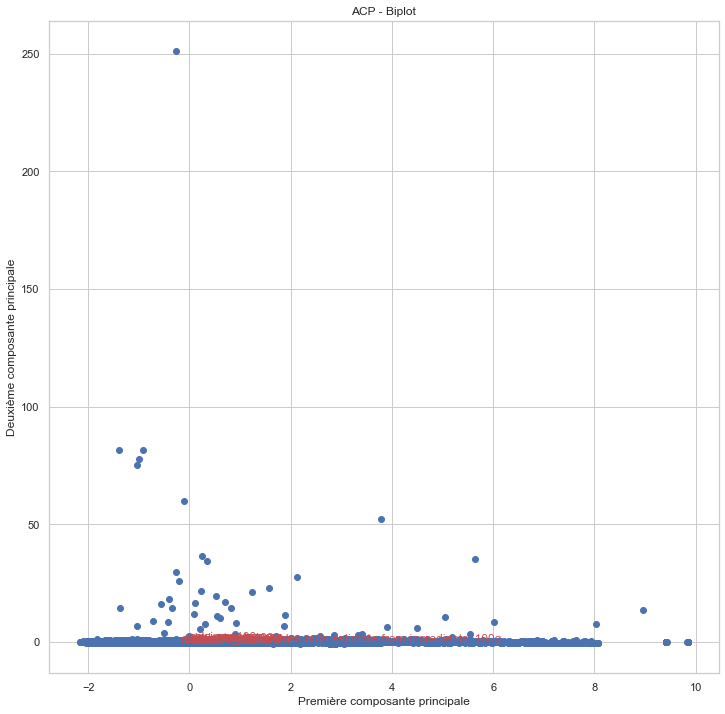

In [162]:
plt.scatter(selected_components[:, 0], selected_components[:, 1])
for i, var_name in enumerate(numeric_cols):
    plt.arrow(0, 0, pca.components_[0, i], pca.components_[1, i], color='r', alpha=0.5)
    plt.text(pca.components_[0, i]*1.1, pca.components_[1, i]*1.1, var_name, color='r')

plt.xlabel('Première composante principale')
plt.ylabel('Deuxième composante principale')
plt.title('ACP - Biplot')
plt.show()

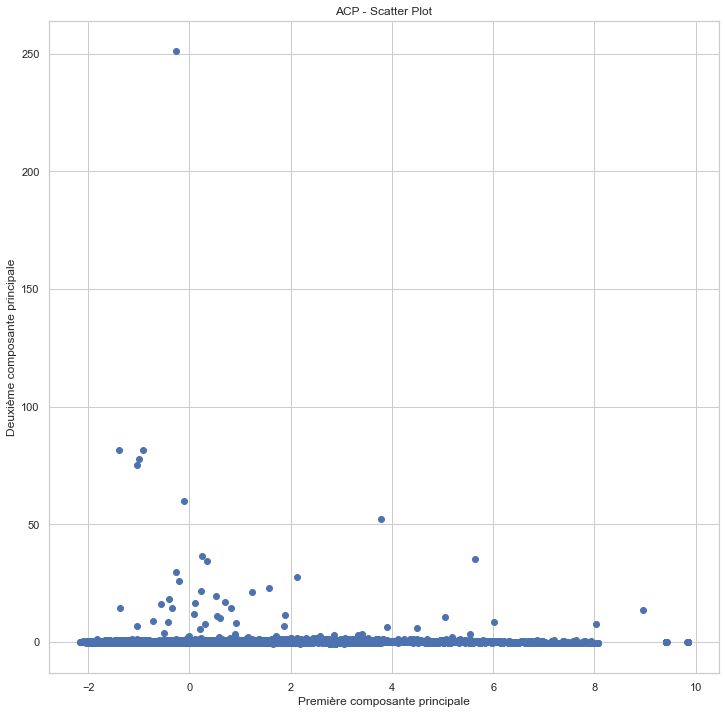

In [161]:
plt.scatter(selected_components[:, 0], selected_components[:, 1])
plt.xlabel('Première composante principale')
plt.ylabel('Deuxième composante principale')
plt.title('ACP - Scatter Plot')
plt.show()

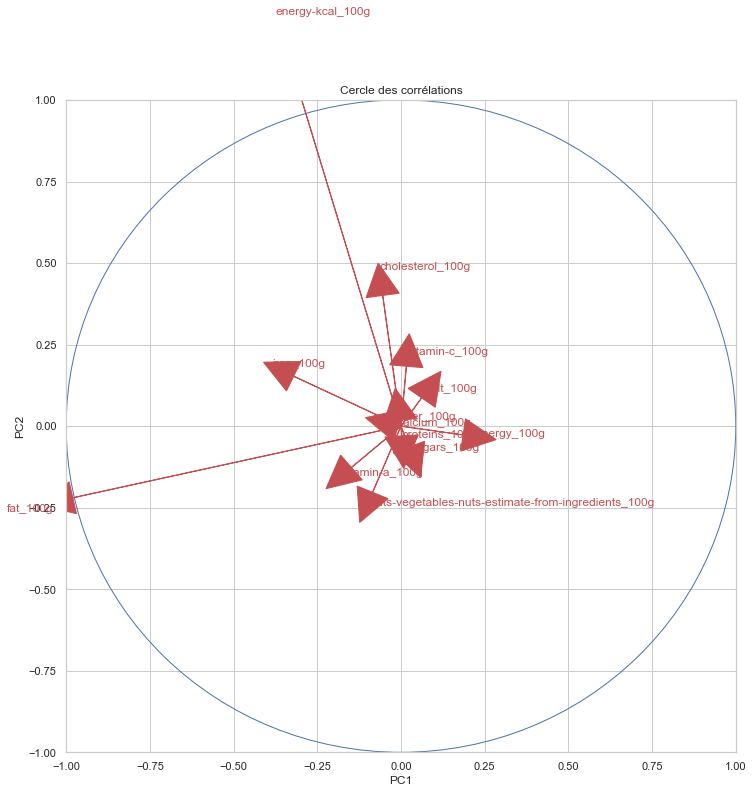

In [163]:
# Obtenez les valeurs propres (variance expliquée)
eigenvalues = pca.explained_variance_

# Obtenez les vecteurs propres (composantes principales)
eigenvectors = pca.components_

# Calculez la variance expliquée cumulée
explained_variance_ratio_cumsum = np.cumsum(pca.explained_variance_ratio_)

# Créez la figure et les axes
fig, ax = plt.subplots()

# Tracer les variables sur le cercle des corrélations
for i, (eigenvalue, eigenvector) in enumerate(zip(eigenvalues, eigenvectors)):
    ax.arrow(0, 0, eigenvalue * eigenvector[0], eigenvalue * eigenvector[1], 
             head_width=0.1, head_length=0.1, fc='r', ec='r')
    ax.text(eigenvalue * eigenvector[0] * 1.2, eigenvalue * eigenvector[1] * 1.2,
            train.columns[i], color='r')

# Tracer le cercle unitaire
circle = plt.Circle((0, 0), 1, color='b', fill=False)
ax.add_patch(circle)

# Définir les limites des axes
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

# Définir les étiquettes des axes
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# Ajouter un titre
ax.set_title('Cercle des corrélations')

# Afficher le graphique
plt.show()

## Test Anova 

In [22]:
nutriscore_range = train['nutriscore_score'].max()-train['nutriscore_score'].min()
print('Gap in each bin :',nutriscore_range/5)

Gap in each bin : 11.0


In [23]:
starting_value = -15
# Gap rounded up 
gap = 11
bins=[]
for i in range(6):
    bins.append(starting_value+i*gap)
labels=['a','b','c','d','e']


train['binned'] = pd.cut(train['nutriscore_score'], bins=bins, labels=labels)
train.head()

,energy-kcal_100g,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,...,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g,nutrition-score-fr_100g,nutriscore_score,nutriscore_grade,nova_group,binned
0,571.000000,2389.0,46.430000,7.14,0.0,0.000,39.290000,3.570000,7.100000,7.140000,...,0.000000,0.000000,0.000000,0.001290,0.000000,19.0,19.0,e,4.0,d
1,311.111111,1302.0,1.111111,0.00,0.0,0.000,62.222222,2.222222,2.222222,13.333333,...,0.000000,0.222222,0.022222,0.000889,0.000000,-4.0,-4.0,a,1.0,a
2,415.000000,1736.0,23.170000,7.32,0.0,0.073,47.560000,36.590000,1.200000,3.660000,...,0.000037,0.000000,0.024000,0.001320,0.000000,22.0,22.0,e,4.0,d
3,533.000000,2230.0,43.330000,6.67,0.0,0.000,26.670000,13.330000,3.300000,23.330000,...,0.000000,0.000000,0.033000,0.003000,16.666667,13.0,13.0,d,4.0,c
4,393.000000,1644.0,32.140000,21.43,0.0,0.107,0.000000,0.000000,0.000000,25.000000,...,0.000321,0.000000,0.714000,0.000000,0.000000,15.0,15.0,d,3.0,c


In [25]:
cols = train.columns[:-3].tolist()
cols    

['energy-kcal_100g',
 'energy_100g',
 'fat_100g',
 'saturated-fat_100g',
 'trans-fat_100g',
 'cholesterol_100g',
 'carbohydrates_100g',
 'sugars_100g',
 'fiber_100g',
 'proteins_100g',
 'salt_100g',
 'sodium_100g',
 'vitamin-a_100g',
 'vitamin-c_100g',
 'calcium_100g',
 'iron_100g',
 'fruits-vegetables-nuts-estimate-from-ingredients_100g',
 'nutrition-score-fr_100g',
 'nutriscore_score']

In [26]:
F, p = stats.f_oneway(train.loc[train["binned"] == 'a',cols],
                      train.loc[train["binned"] == 'b',cols],
                      train.loc[train["binned"] == 'c',cols],
                      train.loc[train["binned"] == 'd',cols],
                      train.loc[train["binned"] == 'e',cols])

# F, p = stats.f_oneway(train.loc[train["binned"] == 'a','energy_100g'],
#                       train.loc[train["binned"] == 'b','energy_100g'],
#                       train.loc[train["binned"] == 'c','energy_100g'],
#                       train.loc[train["binned"] == 'd','energy_100g'],
#                       train.loc[train["binned"] == 'e','energy_100g'])
F, p

(array([1.26698789e+04, 1.27600148e+04, 6.75000112e+03, 1.16373438e+04,
        3.02033521e+01, 1.61056321e+00, 3.21883390e+03, 5.78410218e+03,
        2.16197968e+03, 6.81248582e+02, 6.65629986e+01, 6.65006420e+01,
        3.78736806e+00, 1.55353895e+00, 9.11745857e+01, 2.48446987e+00,
        2.08243478e+03, 1.90442390e+05, 1.90442390e+05]),
 array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        3.75443994e-25, 1.68477870e-01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 2.59124472e-56, 2.93139703e-56,
        4.40364176e-03, 1.83727905e-01, 1.82725445e-77, 4.14963706e-02,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]))

In [27]:
results_anova =pd.DataFrame(columns=['F','P_value'])
for i in range(len(cols)):
    results_anova.loc[cols[i]]=[F[i],p[i]]
results_anova   

,F,P_value
energy-kcal_100g,12669.878912,0.000000e+00
energy_100g,12760.014798,0.000000e+00
fat_100g,6750.001124,0.000000e+00
saturated-fat_100g,11637.343767,0.000000e+00
trans-fat_100g,30.203352,3.754440e-25
cholesterol_100g,1.610563,1.684779e-01
carbohydrates_100g,3218.833904,0.000000e+00
sugars_100g,5784.102180,0.000000e+00
fiber_100g,2161.979679,0.000000e+00
proteins_100g,681.248582,0.000000e+00


Ces résultats indiquent que pour toutes les variables, à l'exception de cholesterol_100g, vitamin-a_100g et vitamin-c_100g, il existe des différences significatives entre les groupes. La valeur-P de 0.0 pour ces variables indique qu'il y a une forte association entre les variables et la variable cible.

<AxesSubplot:xlabel='energy_100g', ylabel='binned'>

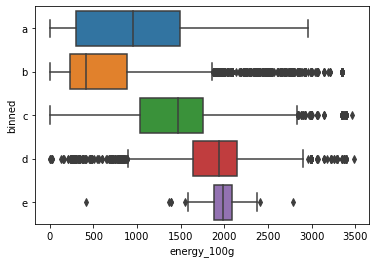

In [28]:
sns.boxplot(y='binned',x='energy_100g',data=train)


## Test de Chi2

In [5]:
from scipy.stats import chi2_contingency

# Sélectionnez les variables catégorielles appropriées dans votre DataFrame
variable_cat_1 = train['nutriscore_grade']
variable_cat_2 = train['nova_group']

# Créez une table de contingence entre les deux variables catégorielles
contingency_table = pd.crosstab(variable_cat_1, variable_cat_2)

# Appliquez le test du chi2 sur la table de contingence
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Affichez les résultats
print("Statistique du chi2 :", chi2)
print("Valeur-P :", p_value)
print("Degrés de liberté :", dof)

Statistique du chi2 : 24121.0213933612
Valeur-P : 0.0
Degrés de liberté : 12


Dans ce cas, la valeur-P est très proche de zéro, ce qui suggère que les variables catégorielles sont fortement dépendantes les unes des autres. Autrement dit, il y a une relation significative entre les variables catégorielles testées (nutriscore_grade, nova_group) dans notre DataFrame.